In [1]:
import os
import warnings
import csv
import glob
import sys
import requests

import earthaccess
from osgeo import gdal

import pandas as pd
import numpy as np
import xarray as xr
import math

import rasterio
from rasterio.transform import Affine
import rasterio as rio

import netCDF4 as nc
from datetime import datetime, timedelta, timezone

from scipy import ndimage as ndi
from scipy.ndimage import binary_fill_holes, center_of_mass
from scipy.interpolate import PchipInterpolator  # monotone, shape-preserving

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from lxml import etree
from scipy import linalg

from scipy.ndimage import gaussian_filter, binary_erosion, binary_dilation, rotate, shift
from skimage.morphology import binary_erosion
from skimage.transform import hough_line, hough_line_peaks
from skimage.restoration import (
    denoise_tv_chambolle,
    denoise_bilateral,
    denoise_wavelet,
    estimate_sigma,
    inpaint_biharmonic
)

# This will ignore some warnings caused by holoviews
warnings.simplefilter('ignore') 

sys.path.append('../../EMIT-Data-Resources/python/modules/')
from emit_tools import emit_xarray, ortho_xr

sys.path.append('../')
from config import *
from test_runs import *

sys.path.append('../../datasets/')
import get_geosfp
import get_campd
import importlib

# Reload the module
importlib.reload(get_campd)
importlib.reload(get_geosfp)

get_emission_rate = get_campd.get_emission_rate
get_emissions = get_campd.get_emissions

get_geosfp_wind = get_geosfp.get_geosfp_wind
get_geosfp_tph = get_geosfp.get_geosfp_tph


wav_min = 418
wav_max = 492
bin_size = 4
polydeg = 3

help(emit_xarray)

Help on function emit_xarray in module emit_tools:

emit_xarray(filepath, ortho=False, qmask=None, unpacked_bmask=None)
    This function utilizes other functions in this module to streamline opening an EMIT dataset as an xarray.Dataset.
    
    Parameters:
    filepath: a filepath to an EMIT netCDF file
    ortho: True or False, whether to orthorectify the dataset or leave in crosstrack/downtrack coordinates.
    qmask: a numpy array output from the quality_mask function used to mask pixels based on quality flags selected in that function. Any non-orthorectified array with the proper crosstrack and downtrack dimensions can also be used.
    unpacked_bmask: a numpy array from  the band_mask function that can be used to mask band-specific pixels that have been interpolated.
    
    Returns:
    out_xr: an xarray.Dataset constructed based on the parameters provided.



In [278]:
PLANT_GRANULES

{'New_Madrid_Power_Plant': ['20250401T172306_2509111_025',
  '20241012T201651_2428613_043',
  '20250927T182549_2527011_024'],
 'Limestone': [],
 'Fort_Martin_Power_Station': [],
 'Ninemile_Point': [],
 'Scherer': [],
 'Ghent': [],
 'Miami_Fort_Power_Station': ['20251001T165203_2527410_031'],
 'Hunter': [],
 'Labadie': [],
 'W_A_Parish': [],
 'Thomas_Hill_Energy_Center': [],
 'Belle_River': [],
 'Intermountain': ['20240804T181803_2421712_014',
  '20241001T191716_2427513_010',
  '20231005T183601_2327812_013',
  '20241005T174121_2427912_013',
  '20250424T164449_2511411_003'],
 'Milton_R_Young': [],
 'Cayuga': [],
 'Bridger': []}

In [5]:
PREFIXES

{'OBS': 'EMIT_L1B_OBS_001_',
 'L1B': 'EMIT_L1B_RAD_001_',
 'MASK': 'EMIT_L2A_MASK_001_',
 'L2A': 'EMIT_L2A_RFL_001_'}

In [15]:
fp_mask = f"{CONFIG['data_folder']}/{loc_name}/{PREFIXES['MASK']}{granule_name}.nc"
# mask_parameters_ds = xr.open_dataset(fp_mask,engine = 'h5netcdf', group='sensor_band_parameters')
# mask_key = mask_parameters_ds['mask_bands'].to_dataframe()
# mask_key

In [17]:
fp_mask

'/Volumes/T9/EMIT-NOX/data/EMIT/New_Madrid_Power_Plant/EMIT_L2A_MASK_001_20250401T172306_2509111_025.nc'

In [18]:
loc_name = 'New_Madrid_Power_Plant'
granule_name = PLANT_GRANULES[loc_name][0]
print(f"LOC_NAME: {loc_name}\nGRANULE: {granule_name}")

loc_type = 'plant'

if loc_type == 'plant':
    loc_data = POWER_PLANTS[loc_name]
else:
    loc_data = LOCS[loc_name]

retrieval_fpath = f"{CONFIG['results_folder']}/{loc_name}/dSCD_{PREFIXES['L1B']}{granule_name}.npy"
radiance_fpath = f"{CONFIG['data_folder']}/{loc_name}/{PREFIXES['L1B']}{granule_name}.nc"

obs_time = datetime.strptime(granule_name.split('_')[0], "%Y%m%dT%H%M%S").replace(tzinfo=timezone.utc)

campd_e_rate = get_emission_rate(loc_data, obs_time, timedelta(hours=4))
# campd_e_rate = 0.18
print(f"campd emission rate for 4 hours prior: {campd_e_rate:0.2f} kg/s")

wind_info = get_geosfp_wind(loc_data['LAT'], loc_data['LON'], obs_time, cache=f'{CONFIG["geosfp"]}/')
wind_info

LOC_NAME: New_Madrid_Power_Plant
GRANULE: 20250401T172306_2509111_025
campd emission rate for 4 hours prior: 0.59 kg/s


{'U2': 3.320873357829067,
 'DIR2': 123.85217606350808,
 'U10': 4.367135303110725,
 'DIR10': 123.83872148006431,
 'U50': 5.090010083588581,
 'DIR50': 124.77788867977425,
 'U500_log': 6.466245869308874,
 'U500_power': 7.115241828011127,
 'z0_fit': 0.0058728332453671485,
 'alpha': 0.09517145913627122,
 'log_law': <function get_geosfp.get_geosfp_wind.<locals>.<lambda>(z)>,
 'power_law': <function get_geosfp.get_geosfp_wind.<locals>.<lambda>(z)>,
 'surface_pressure_Pa': 100522.4140625}

In [280]:
ds_no_orth = emit_xarray(radiance_fpath, ortho=False)
retrieval = np.load(retrieval_fpath)

dSCD = np.load(retrieval_fpath)
ds_no_orth = emit_xarray(radiance_fpath)

wl_val = float(ds_no_orth["wavelengths"].isel(wavelengths=0))  # or a specific value
dscd_da = xr.DataArray(
    dSCD.astype('float32')[..., None],  # -> (downtrack, crosstrack, 1)
    dims=("downtrack", "crosstrack", "wavelengths"),
    coords={
        "downtrack": ds_no_orth["downtrack"],
        "crosstrack": ds_no_orth["crosstrack"],
        "wavelengths": [wl_val],
    },
    name="dSCD",
    attrs={
        "long_name": "Differential Slant Column Density (single band)",
        "units": "molec cm^-2",
    },
)
ds_no_orth = ds_no_orth.assign(dSCD=dscd_da)
ds = ortho_xr(ds_no_orth)

(dy, dx) = ds.rio.resolution() # in deg
pix_pitch_m = 111000 * abs(dy)

del ds_no_orth

bounds = (np.min(ds['longitude'].values), np.max(ds['longitude'].values),
          np.min(ds['latitude'].values),  np.max(ds['latitude'].values))

# axs[i].imshow(ds['radiance'][:,:,0], cmap='gray', extent=bounds)
rad1500 = ds['radiance'].sel(wavelengths=1500, method='nearest').values
dSCD_nan = np.where(rad1500 <= -8000, np.nan, ds['dSCD'].values[:,:,0])*1e19

Text(0, 0.5, 'latitude')

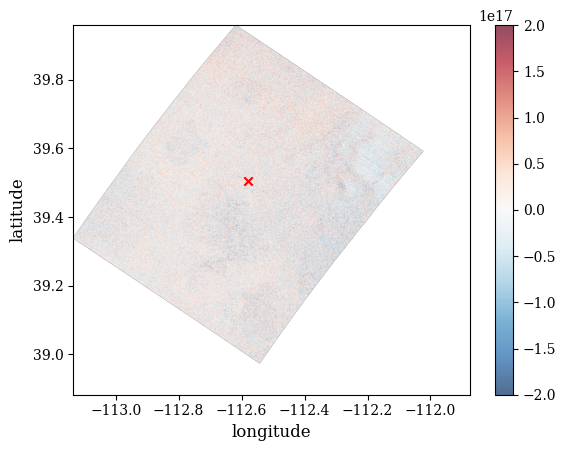

In [281]:
plt.imshow(dSCD_nan, cmap='RdBu_r', origin='upper', 
              aspect='auto', vmin=-2e17, vmax=2e17, extent=bounds, alpha=0.7)
plt.colorbar()
plt.scatter([loc_data['LON']], [loc_data['LAT']], marker='x', c='red')
plt.xlabel('longitude')
plt.ylabel('latitude')

In [282]:
# Estimate the average noise standard deviation across color channels.
sigma_est = estimate_sigma(dSCD, average_sigmas=True)
# Due to clipping in random_noise, the estimate will be a bit smaller than the
# specified sigma.
print(f'Estimated Gaussian noise standard deviation = {sigma_est}')

mask = np.isfinite(dSCD_nan)

filled = inpaint_biharmonic(dSCD_nan/1e19, ~mask)
tv = denoise_tv_chambolle(filled, weight=0.2)
tv[~mask] = np.nan

Estimated Gaussian noise standard deviation = nan


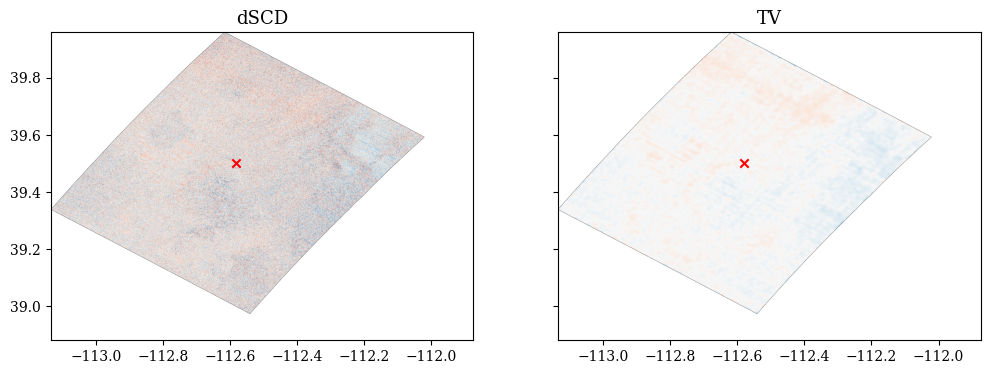

In [283]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4), sharex=True, sharey=True)

ax[0].imshow(dSCD_nan, cmap='RdBu_r', origin='upper', 
              aspect='auto', vmin=-2e17, vmax=2e17, extent=bounds)
ax[0].scatter([loc_data['LON']], [loc_data['LAT']], marker='x', c='red')
ax[0].set_title('dSCD')

ax[1].imshow(tv, cmap='RdBu_r', origin='upper', 
              aspect='auto', vmin=-2e-2, vmax=2e-2, extent=bounds)
ax[1].scatter([loc_data['LON']], [loc_data['LAT']], marker='x', c='red')
ax[1].set_title('TV')

# ax[2].imshow(denoise_tv_chambolle(dSCD_nan, weight=0.2), cmap='RdBu_r')
# ax[2].set_title('(more) TV')

plt.show()

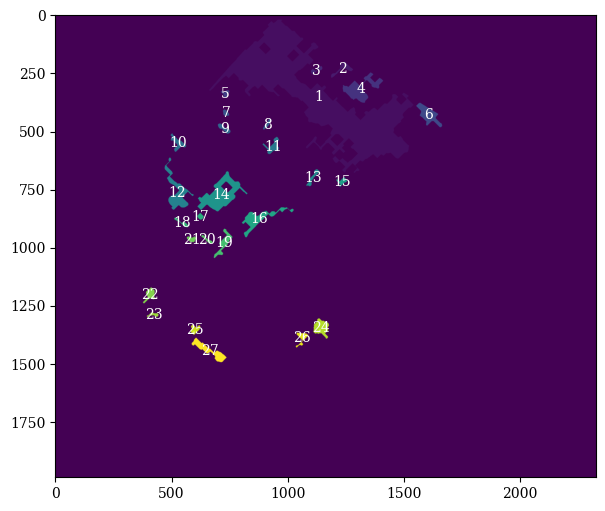

In [293]:
def get_plume_mask(img, pct=97, open_iters=4, close_iters=4, min_size=500):
    """
    img: 2D array (NaNs allowed)
    pct: percentile used for threshold (e.g., 95–99)
    open_iters/close_iters: morphology to denoise/bridge small gaps
    min_size: drop tiny specks before picking the two largest blobs
    """
    # 1) Threshold on high values (tune pct as needed)
    valid = np.isfinite(img)
    thr = np.nanpercentile(img, pct)
    bw = valid & (img >= thr)

    # 2) Morphology to clean the mask
    # Opening removes salt noise; closing bridges small gaps.
    bw = ndi.binary_opening(bw, iterations=open_iters)
    bw = ndi.binary_closing(bw, iterations=close_iters)

    # Remove very small objects
    lbl, n = ndi.label(bw)
    if n == 0:
        return np.zeros_like(bw, bool), np.zeros_like(bw, bool)

    sizes = ndi.sum(np.ones_like(bw), labels=lbl, index=np.arange(1, n+1))
    keep = {i+1 for i, s in enumerate(sizes) if s >= min_size}
    bw = np.isin(lbl, list(keep))

    # Re-label after size filter, fill holes
    lbl, n = ndi.label(bw)
    if n == 0:
        return np.zeros_like(bw, bool), np.zeros_like(bw, bool)
    lbl = ndi.binary_fill_holes(lbl>0).astype(int) * lbl

    return lbl

lbls = get_plume_mask(tv, pct=90, open_iters=3, close_iters=20)

plt.figure(figsize=(10,6))
plt.imshow(lbls, cmap='viridis')# extent=bounds)
# plt.scatter([loc_data['LON']], [loc_data['LAT']], marker='x', c='red')

# unique labels, excluding background (0)
regions = np.unique(lbls)
regions = regions[regions != 0]

for r in regions:
    cy, cx = center_of_mass(lbls == r)
    plt.text(cx, cy, str(r), color='white', fontsize=10, ha='center', va='center')

plt.show()

36737


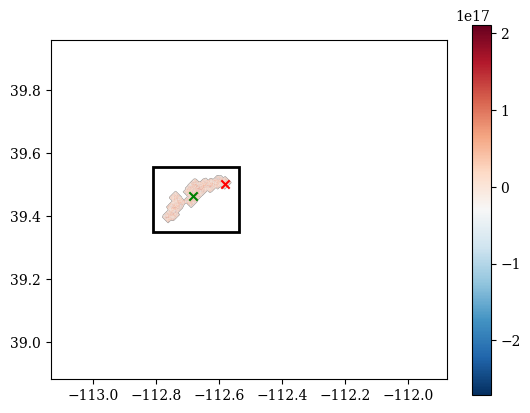

In [294]:
PLUME_ID = [16,19]

plume_mask = np.isin(lbls, PLUME_ID)

plume_mask_filled = binary_fill_holes(plume_mask)
plume_mask_filled = binary_dilation(plume_mask_filled, iterations=30)
plume_mask_filled = binary_fill_holes(plume_mask_filled)

plume_size_init = np.sum([1 if k else 0 for k in plume_mask_filled.flatten()])
print(plume_size_init)

## Get plume dSCD
dSCD_plume_masked = np.where(plume_mask_filled, dSCD_nan, np.nan)

## Get plume center
rows, cols = np.indices(dSCD_plume_masked.shape)
m = np.isfinite(dSCD_plume_masked)
xw = np.nansum(cols[m] * np.clip(dSCD_plume_masked[m], 0, None) ) / np.nansum(np.clip(dSCD_plume_masked[m], 0, None))
yw = np.nansum(rows[m] * np.clip(dSCD_plume_masked[m], 0, None) ) / np.nansum(np.clip(dSCD_plume_masked[m], 0, None))

## Boundary for full image, get a grid for lat/lon
bounds = (np.min(ds['longitude'].values), np.max(ds['longitude'].values),
          np.min(ds['latitude'].values),  np.max(ds['latitude'].values))

lon_grid = np.linspace(np.min(ds['longitude'].values), np.max(ds['longitude'].values), num=dSCD_plume_masked.shape[1])
lat_grid = np.linspace(np.min(ds['latitude'].values), np.max(ds['latitude'].values), num=dSCD_plume_masked.shape[0])

## Get bounding box
y_mask, x_mask = np.where(~np.isnan(dSCD_plume_masked))
pad = 50
bbox = (max(0, x_mask.min()-pad), min(len(lon_grid)-1, x_mask.max()+pad),
        max(-len(lat_grid)+1, -y_mask.min()+pad), min(0, -y_mask.max()-pad))

bounding_box = (lon_grid[bbox[0]], lon_grid[bbox[1]], 
                lat_grid[bbox[2]], lat_grid[bbox[3]])


plt.imshow(dSCD_plume_masked, cmap='RdBu_r', extent=bounds)
plt.colorbar()
plt.scatter([lon_grid[int(xw)]], [lat_grid[-int(yw)]], marker='x', c='g')
plt.scatter([loc_data['LON']], [loc_data['LAT']], marker='x', c='red')

lon_min, lon_max, lat_min, lat_max = bounding_box
rect = patches.Rectangle((lon_min, lat_min), lon_max - lon_min, lat_max - lat_min,
                 linewidth=2, edgecolor='k', facecolor='none')
plt.gca().add_patch(rect)

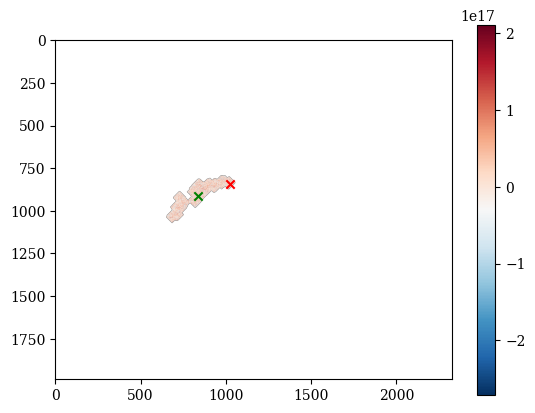

In [295]:
ni = lambda v,a: int(np.argmin(np.abs(a - v)))

source_lat, source_lon = len(lat_grid)-ni(loc_data['LAT'], lat_grid), ni(loc_data['LON'], lon_grid) 
plume_lat, plume_lon = int(yw), int(xw)

plt.imshow(dSCD_plume_masked, cmap='RdBu_r')
plt.colorbar()
plt.scatter([plume_lon], [plume_lat], marker='x', c='g')
plt.scatter([source_lon], [source_lat], marker='x', c='red')

38628


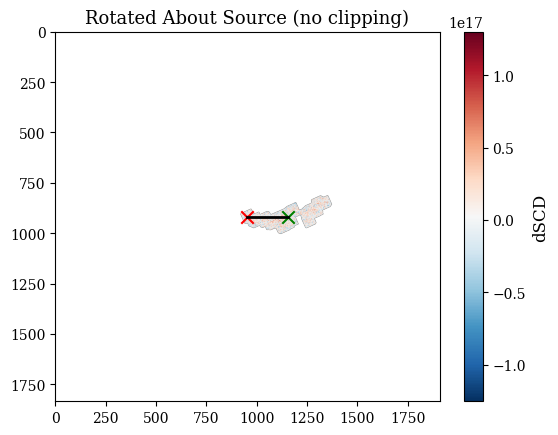

In [296]:
# --- helpers ---
ni = lambda v,a: int(np.argmin(np.abs(a - v)))

# pixel indices (global)
Rr,Rc = len(lat_grid)-ni(loc_data['LAT'], lat_grid), ni(loc_data['LON'], lon_grid) 
Gr, Gc = int(yw), int(xw)

# tight crop (with pad)
ym,xm = np.where(np.isfinite(dSCD_plume_masked)); pad=50
r0,r1 = max(0, ym.min()-pad), min(dSCD_plume_masked.shape[0], ym.max()+pad+1)
c0,c1 = max(0, xm.min()-pad), min(dSCD_plume_masked.shape[1], xm.max()+pad+1)
img   = dSCD_plume_masked[r0:r1, c0:c1].copy()
Rr,Rc,Gr,Gc = Rr-r0, Rc-c0, Gr-r0, Gc-c0

# plt.imshow(img); plt.scatter([Rc], [Rr]); plt.scatter([Gc], [Gr]); plt.show()

# angle to make red→green horizontal to the RIGHT
dx, dy = (Gc-Rc), (Gr-Rr)
angle  = -np.degrees(np.arctan2(-dy, dx))   # rotate by this

# pad so nothing clips; shift so RED at center
H,W = img.shape; P = max(H,W)
img  = np.pad(img, P, constant_values=np.nan)
Rr,Rc,Gr,Gc = Rr+P, Rc+P, Gr+P, Gc+P
H,W = img.shape; cy, cx = H/2, W/2

valid = np.isfinite(img).astype(float)

# plt.imshow(valid); plt.scatter([Rc], [Rr]); plt.scatter([Gc], [Gr]); plt.show()

vals  = np.nan_to_num(img, nan=0.0)
shift_vec = (cy - Rr, cx - Rc)
vals  = shift(vals,  shift_vec, order=1, mode='constant', cval=0.0, prefilter=False)
valid = shift(valid, shift_vec, order=1, mode='constant', cval=0.0, prefilter=False)

# plt.imshow(valid)
# print(vals.shape)
# print(valid.shape)

# normalized rotation (preserve plume; expand canvas)
num = rotate(vals*valid, angle, reshape=True, order=1, mode='constant', cval=0.0, prefilter=False)
den = rotate(valid,      angle, reshape=True, order=1, mode='constant', cval=0.0, prefilter=False)
with np.errstate(divide='ignore', invalid='ignore'):
    img_rot = num/den
img_rot[den < 1e-6] = np.nan

# plt.imshow(img_rot);
# print(np.isnan(img_rot))
plume_size_rot = np.sum([0 if k else 1 for k in np.isnan(img_rot.flatten())])
print(plume_size_rot)

# rotate GREEN relative to RED using the CORRECT image-space mapping
theta = np.deg2rad(-angle); c,s = np.cos(theta), np.sin(theta)
x_r =  c*dx - s*dy
y_r =  s*dx + c*dy

# red is now at canvas center; green goes to the right at same y
Rx, Ry = img_rot.shape[1]/2, img_rot.shape[0]/2
Gx, Gy = Rx + x_r, Ry + y_r   # Gy == Ry (horizontal), x_r > 0 (to the right)

# plot in pixel space (no lon/lat ticks)
plt.figure()
vmin, vmax = np.nanpercentile(img, [1,99]) if np.isfinite(img).any() else (None,None)
plt.imshow(img_rot, origin='upper', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(label='dSCD')
plt.plot([Rx, Gx], [Ry, Gy], 'k-', lw=2)        # horizontal by construction
plt.scatter([Rx],[Ry], c='r', marker='x', s=80) # source (center)
plt.scatter([Gx],[Gy], c='g', marker='x', s=80) # plume center (to the right)
ax=plt.gca()
# ax.set_xticks([]); ax.set_yticks([]); 
ax.set_aspect('equal','box')
plt.title('Rotated About Source (no clipping)')
plt.show()

In [297]:
obs_fpath  = f"{CONFIG['data_folder']}/{loc_name}/EMIT_L1B_OBS_001_{granule_name}.nc"
l2a_fpath  = f"{CONFIG['data_folder']}/{loc_name}/EMIT_L2A_RFL_001_{granule_name}.nc"
mask_fpath = f"{CONFIG['data_folder']}/{loc_name}/EMIT_L2A_MASK_001_{granule_name}.nc"

OBS_xarr = emit_xarray(obs_fpath, ortho=True)
L2A_xarr = emit_xarray(l2a_fpath, ortho=True)
MASK_xarr = emit_xarray(mask_fpath, ortho=True)

albedo440 = L2A_xarr['reflectance'].sel(wavelengths=440, method='nearest').values
albedo440 = np.where(albedo440 > -8000, albedo440, np.nan)

AOD550 = MASK_xarr['mask'][:,:,5]
f_iso = 1.2 # soil, desert, middle value
AOD550 = np.where(AOD550 > -8000, AOD550 * f_iso, np.nan)

# Estimate AOD 440 using https://en.wikipedia.org/wiki/Angstrom_exponent
ang_const = 1.3
AOD440 = AOD550*(440/550)**-ang_const

to_sun_zenith = OBS_xarr['obs'][:,:,4]#np.radians()
to_sun_zenith = np.where(to_sun_zenith > -8000, to_sun_zenith, np.nan)
# to_sun_zenith = np.radians(to_sun_zenith)

to_sensor_zenith = OBS_xarr['obs'][:,:,2]
to_sensor_zenith = np.where(to_sensor_zenith > -8000, to_sensor_zenith, np.nan)
# to_sensor_zenith = np.radians(to_sensor_zenith)

to_sensor_az = OBS_xarr['obs'][:,:,1]
to_sensor_az = np.where(to_sensor_az > -8000, to_sensor_az, np.nan)

to_sun_az = OBS_xarr['obs'][:,:,3]
to_sun_az = np.where(to_sun_az > -8000, to_sun_az, np.nan)

AMF_geo = 1/np.cos(to_sun_zenith) + 1/np.cos(to_sensor_zenith)

rel_azimuth = np.abs(to_sensor_az-to_sun_az)
rel_azimuth = np.radians(rel_azimuth) if (rel_azimuth < 360-rel_azimuth).any() else np.radians(360-rel_azimuth)


elevation = 1000 ## ADD TO CONFIG FILE
profiles = get_geosfp_tph(loc_data['LAT'], loc_data['LON'], obs_time, elevation, cache=CONFIG['geosfp'])
temp_prof = profiles['T']
press_prof = profiles['P']
hgt_prof = profiles['H']

del MASK_xarr
del L2A_xarr
del OBS_xarr

In [304]:
np.nanmean(to_sun_zenith), np.nanmean(to_sensor_zenith), np.degrees(np.nanmean(rel_azimuth)), 

(44.474957, 9.158852, 20.957855)

In [305]:
def box_amf_geometric(sza_deg, vza_deg, no2_ppb, T_K, P_Pa, z_m_edges):
    """
    no2_ppb: array at layer centers [ppb]
    T_K, P_Pa: arrays at layer centers (same length as no2_ppb)
    z_m_edges: edges array length N+1 (monotonic), centers implied between edges
    returns: m_box (len N), amf_geo (scalar)
    """
    mu0 = np.cos(np.deg2rad(sza_deg))
    mu  = np.cos(np.deg2rad(vza_deg))
    secsum = (1.0/mu0 + 1.0/mu)

    # layer thicknesses from edges
    dz = np.diff(z_m_edges)  # meters
    # air number density (ideal gas): n_air = P / (k_B T)
    kB = 1.380649e-23
    n_air = P_Pa / (kB * T_K)  # [molecules/m^3]

    # NO2 mixing ratio to mole fraction
    x = no2_ppb * 1e-9

    # layer vertical NO2 column (molec/m^2)
    vcol_k = x * n_air * dz

    VCD = np.nansum(vcol_k) #+ 1e-30
    weights = vcol_k / VCD  # sums to 1

    m_box_geo = weights * secsum
    amf_geo = np.sum(m_box_geo)
    return m_box_geo, amf_geo

box_geo, box_amf = box_amf_geometric(np.nanmean(to_sun_zenith),
                                     np.nanmean(to_sensor_zenith),
                                     NOX_fine, T_fine, P_fine, H_fine)
box_amf

2.414344150373978

In [306]:
# --- 1) units & sorting (ensure H strictly increasing) ---
Hc  = np.asarray(profiles["H"], dtype=float)
TcC = np.asarray(profiles["T"], dtype=float)
PhPa= np.asarray(profiles["P"], dtype=float)

order = np.argsort(Hc)
Hc, TcC, PhPa = Hc[order], TcC[order], PhPa[order]

T_K   = TcC + 273.15
P_Pa  = PhPa * 100.0

# --- 2) fine vertical grid (centers) ---
z_surf   = Hc[0]
z_step   = z_surf + 500.0                 # step top (~1900 m in your example)
z_top    = float(Hc[-1])                  # or set e.g., 20000.0 for 20 km
dz       = 50.0                           # 50 m layers (tune as you like)

z_centers = np.arange(z_surf + 0.5*dz, z_top, dz)  # layer centers
z_edges   = np.concatenate(([z_surf], 0.5*(z_centers[1:]+z_centers[:-1]), [z_top]))
# If you want edges strictly aligned to dz from the start:
# z_edges = np.arange(z_surf, z_top + dz, dz)
# z_centers = 0.5*(z_edges[1:] + z_edges[:-1])

# --- 3) interpolators ---
# Temperature: direct interpolation (PCHIP is robust & avoids overshoot)
T_interp = PchipInterpolator(Hc, T_K, extrapolate=True)

# Pressure: interpolate ln(P) vs z for an exponential falloff shape
lnP_interp = PchipInterpolator(Hc, np.log(P_Pa), extrapolate=True)

# Evaluate on fine grid
T_K_fine  = T_interp(z_centers)
P_Pa_fine = np.exp(lnP_interp(z_centers))

# (Optional) clamp any tiny/negative numerical artifacts
P_Pa_fine = np.clip(P_Pa_fine, 1.0, None)

# --- 4) build your NOx step profile on the same fine grid ---
# e.g., NOx = 15 ppb from surface to z_step, then 0.5 ppb background above
NOx_ppb_low  = 15.0
NOx_ppb_bg   = 0.5
NOx_ppb_fine = np.where(z_centers <= z_step, NOx_ppb_low, NOx_ppb_bg)

# (Optional) soften the step with a ~50 m transition:
# width = 50.0
# NOx_ppb_fine = NOx_ppb_bg + (NOx_ppb_low - NOx_ppb_bg) * 0.5 * (1 - np.tanh((z_centers - z_step)/width))

# --- 5) now you can use (T_K_fine, P_Pa_fine, z_edges, NOx_ppb_fine)
# with your geometric box-AMF function from earlier

H_fine = z_edges
T_fine = T_K_fine
P_fine = P_Pa_fine

NOX_fine = NOx_ppb_fine

In [308]:
def rayleigh_tau_440(P_Pa, P_surf_Pa, tauR_surf_440=0.1):
    """
    Crude Rayleigh OD at 440 nm scaled by pressure fraction.
    tauR_surf_440 ~ 0.1 is a ballpark; refine if you have better constants.
    """
    return tauR_surf_440 * (P_Pa / P_surf_Pa)

def aerosol_tau_profile_440(AOD550, angstrom, z_m_edges, H_aer=2000.0):
    """
    Split total AOD vertically with exponential decay from surface.
    Move AOD from 550->440 using Angstrom exponent.
    """
    AOD440 = AOD550 * (550.0/440.0)**angstrom
    zc = 0.5*(z_m_edges[1:]+z_m_edges[:-1])
    dz = np.diff(z_m_edges)
    # extinction profile proportional to exp(-z/H)
    w = np.exp(-zc/H_aer) * dz
    w = w / (np.nansum(w)+1e-30)
    tau_aer_k = AOD440 * w
    return tau_aer_k
    
def apply_simple_scattering_shape(
    m_box_geo, no2_ppb, T_K, P_Pa, z_m_edges,
    AOD550, angstrom, sza_deg, vza_deg, P_surf_Pa,
    surface_albedo=0.05  # <-- NEW PARAM
):
    mu0 = np.cos(np.deg2rad(sza_deg))
    mu  = np.cos(np.deg2rad(vza_deg))
    zc = 0.5*(z_m_edges[1:]+z_m_edges[:-1])
    dz = np.diff(z_m_edges)
    kB = 1.380649e-23
    n_air = P_Pa/(kB*T_K)
    x = no2_ppb*1e-9
    vcol_k = x*n_air*dz
    VCD = np.nansum(vcol_k)+1e-30
    shape = vcol_k/VCD

    tauR_k = rayleigh_tau_440(P_Pa, P_surf_Pa)
    order = np.argsort(zc)
    tauR_sorted = tauR_k[order]
    tauR_up_cum = np.cumsum(tauR_sorted[::-1])[::-1]
    tauR_dn_cum = np.cumsum(tauR_sorted)
    inv = np.empty_like(order)
    inv[order] = np.arange(len(order))
    tauR_up = tauR_up_cum[inv]
    tauR_dn = tauR_dn_cum[inv]

    tauA_k = aerosol_tau_profile_440(AOD550, angstrom, z_m_edges)
    tauA_sorted = tauA_k[order]
    tauA_up_cum = np.cumsum(tauA_sorted[::-1])[::-1]
    tauA_dn_cum = np.cumsum(tauA_sorted)
    tauA_up = tauA_up_cum[inv]
    tauA_dn = tauA_dn_cum[inv]

    # --- Include surface albedo effect ---
    T_down = np.exp(-(tauR_dn+tauA_dn)/mu0)
    T_up   = np.exp(-(tauR_up+tauA_up)/mu)
    # simple 1-bounce reflection approximation
    I_up   = T_up * (1 + surface_albedo * T_down)

    # weight: product of down and up paths
    w = T_down * I_up

    # normalize as before
    # # w_eff = w / (np.nansum(w*shape)+1e-30)
    # m_box_eff = m_box_geo * w
    # amf_eff = np.sum(m_box_eff)
    
    w = np.exp(-T_down/mu0) * np.exp(-T_up/mu)
    w_rel = w / (np.nanmax(w) + 1e-30)
    m_box_eff = m_box_geo * w_rel
    amf_eff = np.sum(m_box_eff)
    
    # w_rel = w / np.nanmean(w)      # keep physical trend, fix scaling
    # m_box_eff = m_box_geo * w_rel
    # amf_eff = np.sum(m_box_eff)

    return m_box_eff, amf_eff


angstrom=1.3
albedo_use = 0.17871495775291163#np.nanmean(albedo440)
m_eff, amf_eff = apply_simple_scattering_shape(box_geo, NOX_fine, T_fine, P_fine, H_fine,
                                               np.nanmean(AOD550), angstrom, 
                                               np.nanmean(to_sun_zenith), np.nanmean(to_sensor_zenith), 
                                               profiles['P'][0]*100, albedo_use)
# amf_eff = amf_eff*2
amf_eff = 2 #1.8
amf_eff

2

Approx pixel pitch: 61.72 m/pix
Plume-integrated NO₂ mass (kg·m⁻¹): 5.258e+00


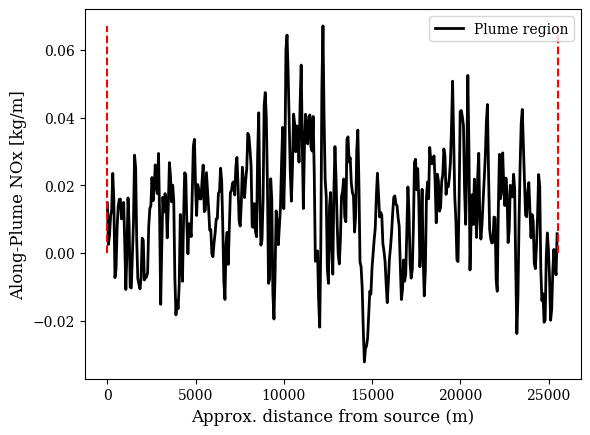

In [309]:
pix_pitch = pix_pitch_m * np.sqrt(plume_size_rot/plume_size_init)
print(f"Approx pixel pitch: {pix_pitch:0.4} m/pix")

AMF = amf_eff
integrated_flux = np.nansum(img_rot, axis=0)*pix_pitch/AMF

# integrated_flux already defined
molec_to_kg_NO2 = 46 / (6.022e23 * 1000)
NOx_NO2_ratio = 1.4 # common value
NO2_kg_m2 = integrated_flux * molec_to_kg_NO2 * NOx_NO2_ratio * 1e4 # cm² → m²

# define indices
start_idx = int(Rx)  # source (red cross)
end_idx = np.where(NO2_kg_m2 > 0)[0][-1]

# threshold = 0.05 * np.nanmax(NO2_kg_m2)  # e.g. 5% of peak as cutoff
# end_idx = start_idx + np.argmax(NO2_kg_m2[start_idx:] < threshold)

# restrict the array
x = np.arange(len(NO2_kg_m2))
NO2_restricted = NO2_kg_m2[start_idx:end_idx]

# compute total plume mass (integrated along track)
plume_mass = np.nansum(NO2_restricted)
print(f"Plume-integrated NO₂ mass (kg·m⁻¹): {plume_mass:.3e}")

plume_extent = x[start_idx:end_idx]*pix_pitch-start_idx*pix_pitch
plume_emission = NO2_kg_m2[start_idx:end_idx]

plt.plot(plume_extent, plume_emission, 'k', lw=2, label='Plume region')
plt.vlines([0, (end_idx-start_idx)*pix_pitch], ymin=0, ymax=np.nanmax(NO2_kg_m2), color='r', linestyles='--')
plt.legend()
plt.xlabel('Approx. distance from source (m)')
plt.ylabel('Along-Plume NOx [kg/m]')
plt.show()


Mean retrieved emission rate: 0.09 kg/s
Mean CAMPD emission rate: 0.09 kg/s


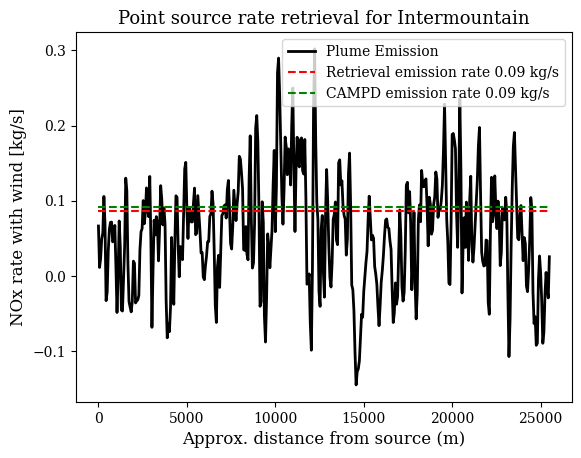

In [312]:
Z = [200, 250, 350, 450, 550, 650, 750]          # m
U = [wind_info["power_law"](z) for z in Z]  # or wind["log_law"](z)

U = [4.5 for k in Z]

Q = [plume_emission * float(u) for u in U]      # kg/s for each z
Q_best = np.mean(Q, axis=0); Q_unc = np.std(Q)

e_rate = np.mean(Q_best[Q_best > 0])
print(f"Mean retrieved emission rate: {e_rate:0.2f} kg/s")

print(f"Mean CAMPD emission rate: {campd_e_rate:0.2f} kg/s")

plt.plot(plume_extent, Q_best, 'k', lw=2, label='Plume Emission')
plt.hlines([e_rate], xmin=0, xmax=np.max(plume_extent), color='red', linestyle='--', 
           label=f'Retrieval emission rate {e_rate:0.2f} kg/s')
plt.hlines([campd_e_rate], xmin=0, xmax=np.max(plume_extent), color='green', linestyle='--', 
           label=f'CAMPD emission rate {campd_e_rate:0.2f} kg/s')

plt.legend()
plt.title(f"Point source rate retrieval for {loc_name}")
plt.xlabel('Approx. distance from source (m)')
plt.ylabel('NOx rate with wind [kg/s]');

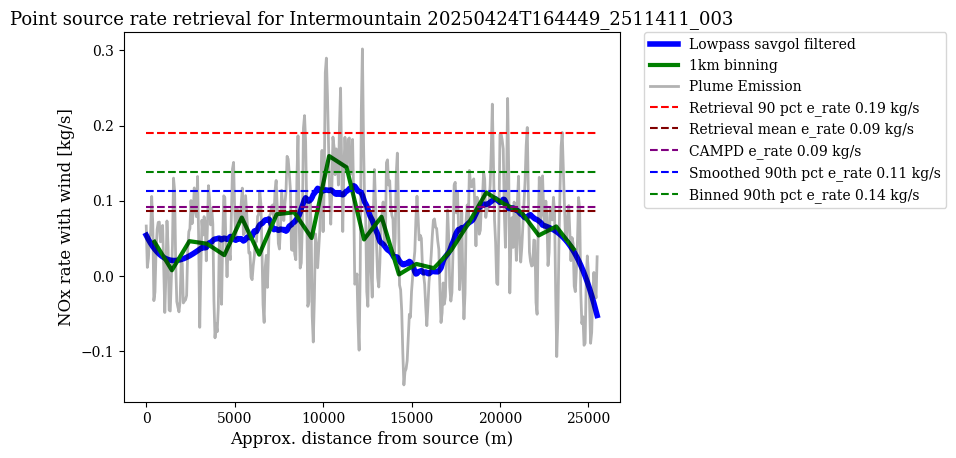

In [313]:
from scipy.signal import savgol_filter
smoothed = savgol_filter(Q_best, window_length=101, polyorder=3) #smooth over 60*101 ~= 6km

# Smooth then base on top 10% of emission data
smoothed_maxrate = np.mean(smoothed[smoothed >= np.percentile(smoothed, 90)])

binned = np.array([np.mean(Q_best[x:x+16]) for x in range(0,len(Q_best)-16,16)])
bin_extent = [np.mean(plume_extent[x:x+16]) for x in range(0,len(Q_best)-16,16)]
bin_maxrate = np.mean(binned[binned >= np.percentile(binned, 90)])
plt.plot(bin_extent, binned)

nofilt_maxrate = np.mean(Q_best[Q_best >= np.percentile(Q_best, 90)])


plt.plot(plume_extent, smoothed,'blue', lw=4, label='Lowpass savgol filtered')
plt.plot(bin_extent, binned, 'green', lw=3, label='1km binning')
plt.plot(plume_extent, Q_best, 'k', lw=2, label='Plume Emission', alpha=0.3)


plt.hlines([nofilt_maxrate], xmin=0, xmax=np.max(plume_extent), color='red', linestyle='--', 
           label=f'Retrieval 90 pct e_rate {nofilt_maxrate:0.2f} kg/s')
plt.hlines([e_rate], xmin=0, xmax=np.max(plume_extent), color='maroon', linestyle='--', 
           label=f'Retrieval mean e_rate {e_rate:0.2f} kg/s')
plt.hlines([campd_e_rate], xmin=0, xmax=np.max(plume_extent), color='purple', linestyle='--', 
           label=f'CAMPD e_rate {campd_e_rate:0.2f} kg/s')
plt.hlines([smoothed_maxrate], xmin=0, xmax=np.max(plume_extent), color='blue', linestyle='--', 
           label=f'Smoothed 90th pct e_rate {smoothed_maxrate:0.2f} kg/s')
plt.hlines([bin_maxrate], xmin=0, xmax=np.max(plume_extent), color='green', linestyle='--', 
           label=f'Binned 90th pct e_rate {bin_maxrate:0.2f} kg/s')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# plt.legend()
plt.title(f"Point source rate retrieval for {loc_name} {granule_name}")
plt.xlabel('Approx. distance from source (m)')
plt.ylabel('NOx rate with wind [kg/s]');

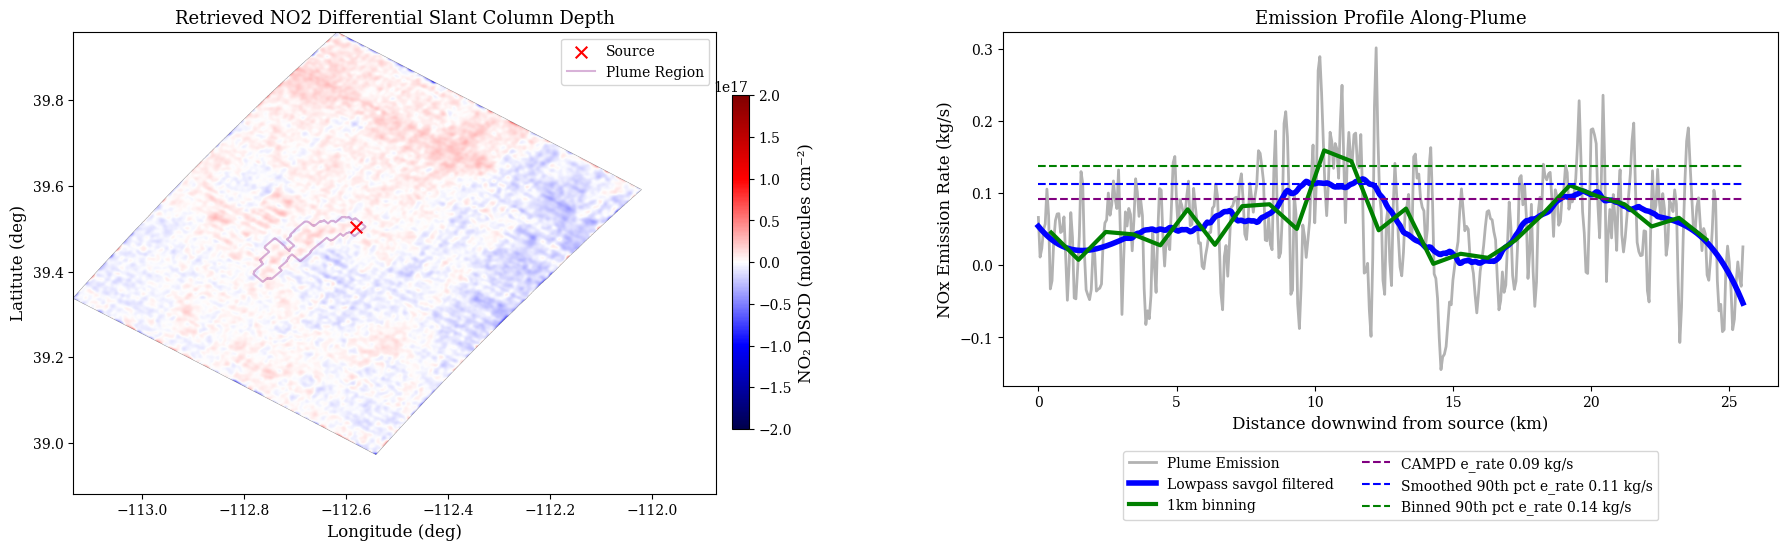

In [314]:
plt.rcParams.update({
    "font.size": 11,
    "font.family": "serif",
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10
})

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(22,6))

plot_img = tv*1e19
# plot_img = dSCD_nan

im = ax[0].imshow(plot_img, cmap='seismic', origin='upper', 
              aspect='auto', vmin=-2e17, vmax=2e17, extent=bounds)
# cb = fig.colorbar(im, ax=ax[0])

cb = fig.colorbar(im, ax=ax[0], shrink=0.85, pad=0.02)
cb.set_label("NO₂ DSCD (molecules cm⁻²)", fontsize=12)
# shrink height and move it down slightly
cb.ax.set_position([
    cb.ax.get_position().x0,          # same left
    cb.ax.get_position().y0 + 0.05,   # move down a bit
    cb.ax.get_position().width,       # same width
    cb.ax.get_position().height * 0.85  # shrink height (0.85 = 85%)
])
ax[0].scatter([loc_data['LON']], [loc_data['LAT']], marker='x', c='red', s=70, label='Source')
ax[0].contour(~np.isnan(dSCD_plume_masked[:,:]), levels=[0.5], 
            colors='purple', alpha=0.3, linestyle='-', linewidths=1.5,
            extent=[bounds[0], bounds[1], bounds[3], bounds[2]])
ax[0].plot([], color='purple', alpha=0.3, label='Plume Region')
ax[0].legend()
ax[0].set_title("Retrieved NO2 Differential Slant Column Depth")
ax[0].set_xlabel("Longitude (deg)")
ax[0].set_ylabel("Latitute (deg)")

ax[1].plot(np.array(plume_extent)/1000, Q_best, 'k', lw=2, label='Plume Emission', alpha=0.3)
ax[1].plot(np.array(plume_extent)/1000, smoothed,'blue', lw=4, label='Lowpass savgol filtered')
ax[1].plot(np.array(bin_extent)/1000, binned, 'green', lw=3, label='1km binning')

ax[1].hlines([campd_e_rate], xmin=0, xmax=np.max(plume_extent)/1000, color='purple', linestyle='--', 
           label=f'CAMPD e_rate {campd_e_rate:0.2f} kg/s')
ax[1].hlines([smoothed_maxrate], xmin=0, xmax=np.max(plume_extent)/1000, color='blue', linestyle='--', 
           label=f'Smoothed 90th pct e_rate {smoothed_maxrate:0.2f} kg/s')
ax[1].hlines([bin_maxrate], xmin=0, xmax=np.max(plume_extent)/1000, color='green', linestyle='--', 
           label=f'Binned 90th pct e_rate {bin_maxrate:0.2f} kg/s')
# ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


# shrink just this subplot height to make room
pos = ax[1].get_position()
ax[1].set_position([pos.x0, pos.y0 + 0.18, pos.width, pos.height - 0.18])

# legend under plot
ax[1].legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.40),
    ncol=2
)

ax[1].set_ylabel("NOx Emission Rate (kg/s)")
ax[1].set_xlabel("Distance downwind from source (km)")
ax[1].set_title("Emission Profile Along-Plume")



# y = np.array([0.74, 0.645, 0.12]).T
# x = np.array([0.59, 0.72, 0.11]).T

y = np.array([0.215, 0.245, 0.115,])#0.37])
x = np.array([0.18,  0.22,  0.14,])#  0.19])


# --- scatter ---
# ax[2].scatter(x, y, label="Retrievals")

# --- best fit line ---
coef = np.polyfit(x, y, 1)     # slope, intercept
m, b = coef
y_pred = m * x + b

# R^2
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - ss_res/ss_tot

# line for plotting
x_line = np.linspace(0, 0.4, 100)
y_line = m * x_line + b

label = f"y = {m:.3f}x + {b:.3f}\n$R^2$ = {r2:.3f}"

# ax[2].plot(x_line, y_line, label=label, linestyle='--')

# # legend
# ax[2].legend()

# # labels (optional)
# ax[2].set_title("Retrievals for Intermountain Power Plant")
# ax[2].set_xlabel("Actual Emission Rate (EPA CAMPD, kg/s)")
# ax[2].set_ylabel("Retrieved Emission Rate (kg/s)")


# fig.savefig(
#     "retrieval_figure_intermountain.png",
#     dpi=600,            # publication-quality
#     bbox_inches="tight",
#     pad_inches=0.05,    # small border
#     facecolor="white"   # ensures no transparency issues
# )

In [163]:
geosfpfn = '/Volumes/T9/EMIT-NOX/GEOS_FP/GEOS.fp.asm.tavg3_3d_asm_Nv.20250424_1630.V01.nc4'


geosfp_3d_data = xr.load_dataset(geosfpfn)
geosfp_3d_data

<xarray.Dataset> Size: 3GB
Dimensions:  (lon: 1152, lat: 721, lev: 72, time: 1)
Coordinates:
  * lon      (lon) float64 9kB -180.0 -179.7 -179.4 -179.1 ... 179.1 179.4 179.7
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lev      (lev) float64 576B 1.0 2.0 3.0 4.0 5.0 ... 68.0 69.0 70.0 71.0 72.0
  * time     (time) datetime64[ns] 8B 2025-04-24T16:30:00
Data variables: (12/16)
    DELP     (time, lev, lat, lon) float32 239MB 1.0 1.0 ... 1.526e+03 1.526e+03
    EPV      (time, lev, lat, lon) float32 239MB 0.02143 0.02143 ... 8.155e-07
    H        (time, lev, lat, lon) float32 239MB 7.33e+04 7.33e+04 ... 58.56
    O3       (time, lev, lat, lon) float32 239MB 5.712e-05 ... 9.275e-08
    OMEGA    (time, lev, lat, lon) float32 239MB 2.978e-06 ... -0.04464
    PHIS     (time, lat, lon) float32 3MB 2.772e+04 2.772e+04 ... 0.0 0.0
    ...       ...
    RH       (time, lev, lat, lon) float32 239MB 2.095e-05 2.095e-05 ... 0.9735
    SLP      (time, lat, lon) float32 3MB 1.01e+05 1.01e+05 ... 1.017e+05
    T        (time, lev, lat, lon) float32 239MB 197.7 197.7 ... 264.4 264.4
    U        (time, lev, lat, lon) float32 239MB -11.45 -11.53 ... -0.1857
    V        (time, lev, lat, lon) float32 239MB 15.17 15.1 ... 12.33 12.33
    TAITIME  (time) float64 8B 1.02e+09
Attributes: (12/28)
    Contact:               http://gmao.gsfc.nasa.gov
    Institution:           NASA Global Modeling and Assimilation Office
    History:               Original file generated: Fri Apr 25 03:14:46 2025 GMT
    Filename:              GEOS.fp.asm.tavg3_3d_asm_Nv.20250424_1630.V01.nc4
    Comment:               GMAO filename: f5295_fp.tavg3_3d_asm_Nv.20250424_1...
    Source:                GEOSadas-5_29_5-p6-SLES15 experiment_id: f5295_fp
    ...                    ...
    NorthernmostLatitude:  90.0
    WesternmostLongitude:  -180.0
    EasternmostLongitude:  179.6875
    LatitudeResolution:    0.25
    LongitudeResolution:   0.3125
    DataResolution:        0.25 x 0.3125 (72 native layers)

1552.7104


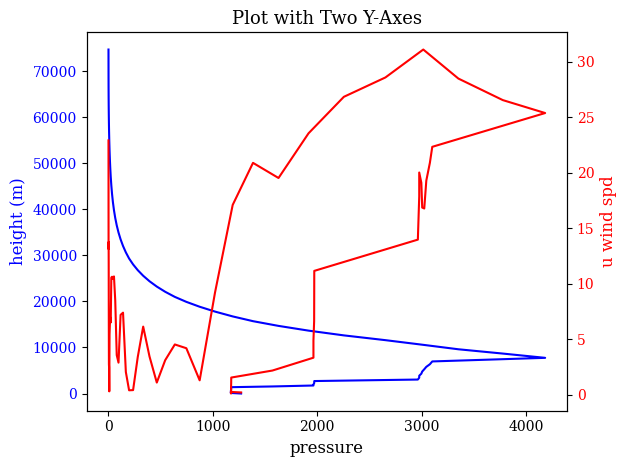

(-5.0, 5.0)

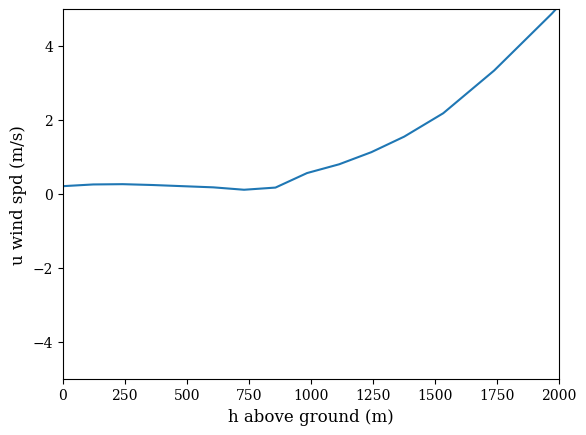

In [215]:
def zero_pad_number(n):
    nstr = str(n)
    if len(nstr) == 1:
        nstr = "0" + nstr
    return nstr

mstr = zero_pad_number(obs_time.month)
dstr = zero_pad_number(obs_time.day)
hstr = zero_pad_number(obs_time.hour)
date_str = f"{obs_time.year}{mstr}{dstr}"
time_str = f"{hstr}30"
new_time_str = f"{obs_time.year}-{mstr}-{dstr}T{hstr}:30:00"

u_profile = geosfp_3d_data.U.sel(time=new_time_str, 
                                 lon=loc_data['LON'], 
                                 lat=loc_data['LAT'], 
                                 method="nearest").values
v_profile = geosfp_3d_data.U.sel(time=new_time_str, 
                                 lon=loc_data['LON'], 
                                 lat=loc_data['LAT'], 
                                 method="nearest").values
u_profile = np.sqrt(u_profile**2 + v_profile**2)

ps_profile = geosfp_3d_data.DELP.sel(time=new_time_str, 
                                 lon=loc_data['LON'], 
                                 lat=loc_data['LAT'], 
                                 method="nearest").values
h_profile = geosfp_3d_data.H.sel(time=new_time_str, 
                                 lon=loc_data['LON'], 
                                 lat=loc_data['LAT'], 
                                 method="nearest").values

print(np.min(h_profile))
h_profile = np.array(h_profile) - np.min(h_profile)

x = ps_profile
y1 = h_profile
y2 = u_profile

# 2. Create the first Axes object
fig, ax1 = plt.subplots()

# 3. Plot the first dataset on the first Axes
ax1.plot(x, y1, 'b-', label='height (m)')
ax1.set_xlabel('pressure')
ax1.set_ylabel('height (m)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# 4. Create the second Axes object using twinx()
ax2 = ax1.twinx()

# 5. Plot the second dataset on the second Axes
ax2.plot(x, y2, 'r-', label='u wind spd')
ax2.set_ylabel('u wind spd', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# 6. Add a title and legend (optional)
plt.title('Plot with Two Y-Axes')
fig.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

plt.plot(h_profile, u_profile)
plt.xlabel('h above ground (m)')
plt.ylabel('u wind spd (m/s)')
plt.xlim(0,2000)
plt.ylim(-5,5)
# plt.plot(ps_profile, u_profile)

In [186]:
u_profile[np.argmin(np.abs(h_profile-500))]

0.20946129

In [216]:
ps_profile[0]

1.0000001